<a href="https://colab.research.google.com/github/chigur-DA/Exploratory-data-analysis-for-online-store/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/mate_analytics
events=pd.read_csv('events.csv')
events.head()

Mounted at /content/drive
/content/drive/MyDrive/mate_analytics


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


## ТАБЛИЦЯ events



In [ ]:
print(events.shape) # дивимось скільки рядків та стовпців у нашій таблиці

(1330, 10)


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
events['Order Date'] = pd.to_datetime(events['Order Date']) # змінив щоб конкретно відображати дату
events['Ship Date'] = pd.to_datetime(events['Ship Date'])

In [ ]:
events['Units Sold'] = events['Units Sold'].astype('int64') # на скільки я розумію даний стовпчик показує кількість проданого, тому перевів в ціле число

In [ ]:
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330,1330,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.201807,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2905.198996,217.323460,176.158873


In [ ]:
print(events.isna().sum()) # бачимо, що в рядках country code є 82 пропущених значення, Unit price є 2 пропущених значення

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
print(events.isna().sum() / events.shape[0] * 100)
#обчислюємо долю пропущених значень

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
events['Country Code'] = events['Country Code'].fillna('Unknown')
# заповнюємо пропущені значення, оскільки великий відсоток відсутніх даних у даній колонці і воно прямо вплине на результат

In [ ]:
events = events.dropna(subset=['Units Sold'])  # видалємо оскільки не впливає на результат

In [ ]:
events['Sales Channel'] = events['Sales Channel'].astype(str).str.strip().str.upper() # видаляємо всі пробіли та переводимо до верхнього регістру
events['Order Priority'] = events['Order Priority'].astype(str).str.strip().str.upper()

In [ ]:
events.duplicated()
print(events.duplicated().sum()) #виводимо кількість рядків з дублікатами

0


In [ ]:
anomalies = events[events['Unit Price'] < events['Unit Cost']] # перевіряємо чи є таке, що ціна менша за собівартість
print(f"Кількість замовлень зі збитком через некоректні ціни: {len(anomalies)}")

Кількість замовлень зі збитком через некоректні ціни: 0


In [ ]:
date_anomalies = events[events['Ship Date'] < events['Order Date']] # перевіряємо чи є таке, що спершу йде дата відправки, а потім дата замовлення
print(f"Кількість аномалій з датами відправки: {len(date_anomalies)}")

Кількість аномалій з датами відправки: 0


In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,ONLINE,650.0,205.70,117.11
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,OFFLINE,1993.0,205.70,117.11
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,ONLINE,4693.0,668.27,502.54
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,ONLINE,1171.0,109.28,35.84
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,OFFLINE,7648.0,47.45,31.79


## ТАБЛИЦЯ products
## Product ID (в таблиці events) = id (в таблиці products)




In [ ]:
products=pd.read_csv('products.csv')
products.head()


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
print(products.shape) # дивимось скільки рядків та стовпців у нашій таблиці

(12, 2)


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
products.describe()

,id
count,12.000000
mean,5802.166667
std,2937.985452
min,1270.000000
25%,2959.000000
50%,6659.500000
75%,8390.000000
max,8969.000000


In [ ]:
print(products.isna().sum()) # бачимо, що неммає пропущених значень

id           0
item_type    0
dtype: int64


In [ ]:
products['item_type'] = products['item_type'].astype(str).str.strip().str.upper()

In [ ]:
products.duplicated()
print(products.duplicated().sum()) #виводимо кількість рядків з дублікатами

0


In [ ]:
products.head()

,id,item_type
0,2103,CEREAL
1,7940,HOUSEHOLD
2,2455,CLOTHES
3,1270,BEVERAGES
4,8681,OFFICE SUPPLIES


## ТАБЛИЦЯ countries
## Country Code (в таблиці events) = alpha-3	(в таблиці countries)

In [ ]:
countries=pd.read_csv('countries.csv')
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
print(countries.shape) # дивимось скільки рядків та стовпців у нашій таблиці

(249, 5)


In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
countries.describe()

,name,alpha-2,alpha-3,region,sub-region
count,249,248,249,248,248
unique,249,248,249,5,17
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


In [ ]:
print(countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
countries = countries.dropna(subset=['alpha-2', 'region', 'sub-region'])  # видалємо оскільки не впливає на результат

In [ ]:
print(f"Кількість дублікатів рядків: {countries.duplicated().sum()}")

Кількість дублікатів рядків: 0


## Data analysis and visualization

In [ ]:
df_merged = events.merge(products, left_on='Product ID', right_on='id', how='left')
df_final = df_merged.merge(countries, left_on='Country Code', right_on='alpha-3', how='left')
df_final.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,ONLINE,650,205.70,117.11,2103,CEREAL,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,OFFLINE,1993,205.70,117.11,2103,CEREAL,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,ONLINE,4693,668.27,502.54,7940,HOUSEHOLD,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,ONLINE,1171,109.28,35.84,2455,CLOTHES,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,OFFLINE,7648,47.45,31.79,1270,BEVERAGES,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
columns_to_drop = ['id', 'alpha-2', 'alpha-3'] # колонки, які ми видаляємо, оскільки вони дублюються
df_final = df_final.drop(columns=columns_to_drop, axis=1) # по вертикалі

In [ ]:
df_final = df_final.rename(columns={
    'name': 'Country Name',
    'item_type': 'Product Category'})
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1328 non-null   int64         
 1   Order Date        1328 non-null   datetime64[ns]
 2   Ship Date         1328 non-null   datetime64[ns]
 3   Order Priority    1328 non-null   object        
 4   Country Code      1328 non-null   object        
 5   Product ID        1328 non-null   int64         
 6   Sales Channel     1328 non-null   object        
 7   Units Sold        1328 non-null   int64         
 8   Unit Price        1328 non-null   float64       
 9   Unit Cost         1328 non-null   float64       
 10  Product Category  1328 non-null   object        
 11  Country Name      1246 non-null   object        
 12  region            1246 non-null   object        
 13  sub-region        1246 non-null   object        
dtypes: datetime64[ns](2), fl

In [ ]:
df_final['Revenue'] = df_final['Units Sold'] * df_final['Unit Price']
df_final['Profit'] = df_final['Units Sold'] * (df_final['Unit Price'] - df_final['Unit Cost'])

total_orders = df_final['Order ID'].nunique() # рахуємо саме унікальні ID замовлень
total_revenue = df_final['Revenue'].sum()
total_profit = df_final['Profit'].sum()
unique_countries = df_final['Country Name'].nunique()
avg_order_value = total_revenue / total_orders

print(f"Загальна кількість замовлень: {total_orders}")
print(f"Загальна виручка: ${total_revenue:,.2f}")
print(f"Загальний прибуток: ${total_profit:,.2f}")
print(f"Охоплено країн: {unique_countries}")
print(f"Середня вартість замовлення: ${avg_order_value:,.2f}")

Загальна кількість замовлень: 1328
Загальна виручка: $1,702,129,408.21
Загальний прибуток: $501,434,459.00
Охоплено країн: 45
Середня вартість замовлення: $1,281,723.95


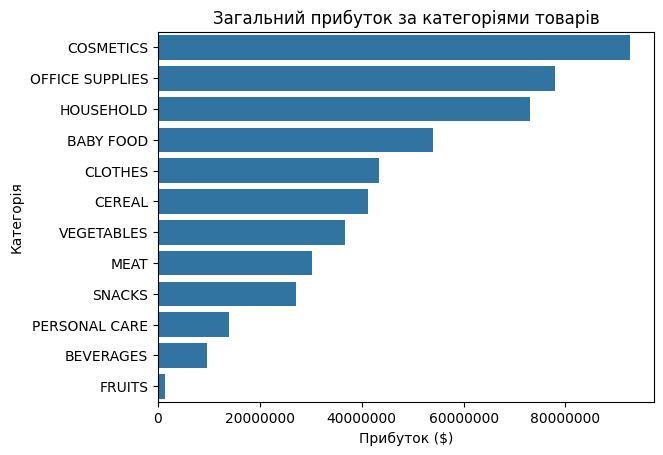

In [ ]:
category_analysis_by_Product_Category = df_final.groupby('Product Category')[['Units Sold', 'Revenue', 'Profit']].sum().reset_index() #за категоріями товарів
category_analysis_by_Product_Category = category_analysis_by_Product_Category.sort_values(by='Profit', ascending=False)
sns.barplot(data=category_analysis_by_Product_Category, x='Profit', y='Product Category')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Загальний прибуток за категоріями товарів')
plt.xlabel('Прибуток ($)')
plt.ylabel('Категорія')
plt.show()

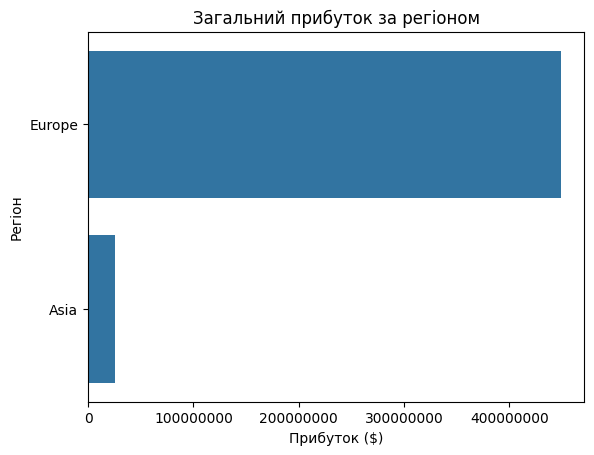

In [ ]:
category_analysis_by_region = df_final.groupby('region')[['Units Sold', 'Revenue', 'Profit']].sum().reset_index() #за категоріями товарів
category_analysis_by_region = category_analysis_by_region.sort_values(by='Profit', ascending=False)
sns.barplot(data=category_analysis_by_region, x='Profit', y='region')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Загальний прибуток за регіоном')
plt.xlabel('Прибуток ($)')
plt.ylabel('Регіон')
plt.show()

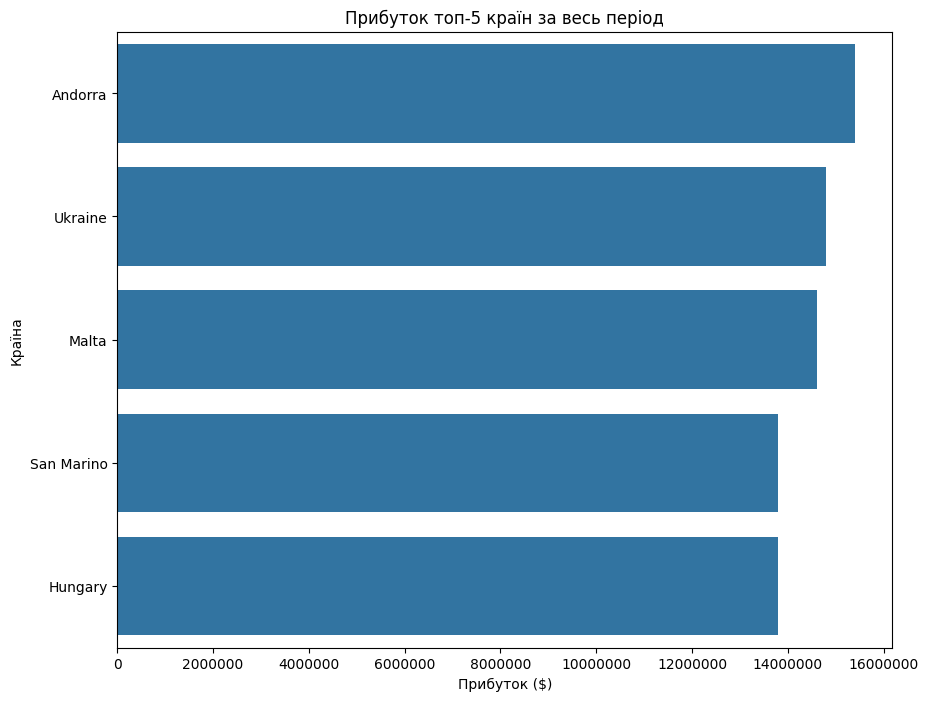

In [ ]:
category_analysis_by_country_name = df_final.groupby('Country Name')[['Units Sold', 'Revenue', 'Profit']].sum().reset_index()
plt.figure(figsize=(10, 8))
category_analysis_by_country_name = category_analysis_by_country_name.sort_values(by='Profit', ascending=False).head(5)
sns.barplot(data=category_analysis_by_country_name, x='Profit', y='Country Name')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Прибуток топ-5 країн за весь період')
plt.xlabel('Прибуток ($)')
plt.ylabel('Країна')
plt.show()

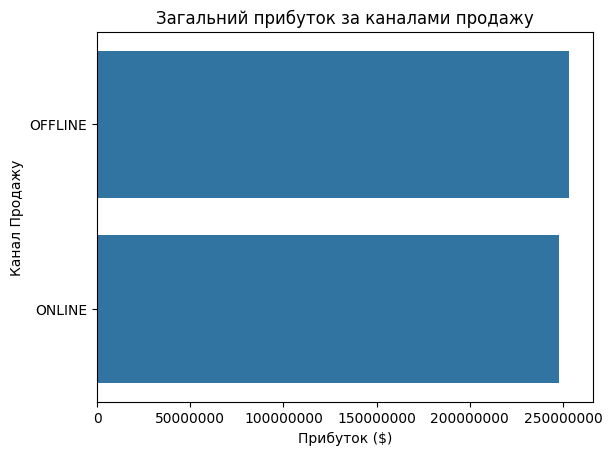

In [ ]:
category_analysis_by_Sales_Channel = df_final.groupby('Sales Channel')[['Units Sold', 'Revenue', 'Profit']].sum().reset_index() #за категоріями товарів
category_analysis_by_Sales_Channel = category_analysis_by_Sales_Channel.sort_values(by='Profit', ascending=False)
sns.barplot(data=category_analysis_by_Sales_Channel, x='Profit', y='Sales Channel')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Загальний прибуток за каналами продажу')
plt.xlabel('Прибуток ($)')
plt.ylabel('Канал Продажу')
plt.show()

/tmp/ipykernel_1948/2073343646.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_shipping_by_region, x='Days to Ship', y='region', palette='Oranges_r')


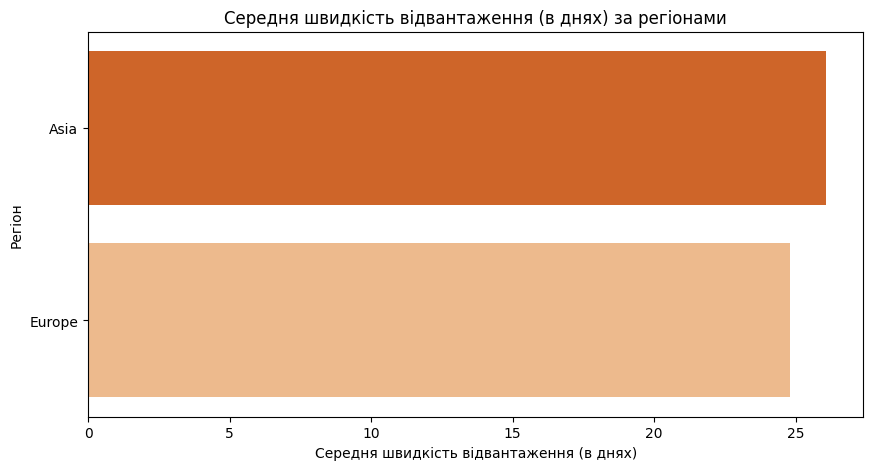

In [ ]:
df_final['Days to Ship'] = (df_final['Ship Date'] - df_final['Order Date']).dt.days
region_shipping_by_region = df_final.groupby('region')['Days to Ship'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=region_shipping_by_region, x='Days to Ship', y='region', palette='Oranges_r')
plt.title('Середня швидкість відвантаження (в днях) за регіонами')
plt.xlabel('Середня швидкість відвантаження (в днях)')
plt.ylabel('Регіон')
plt.show()

/tmp/ipykernel_1948/3429290725.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_shipping_by_Product_Category, x='Days to Ship', y='Product Category', palette='Oranges_r')


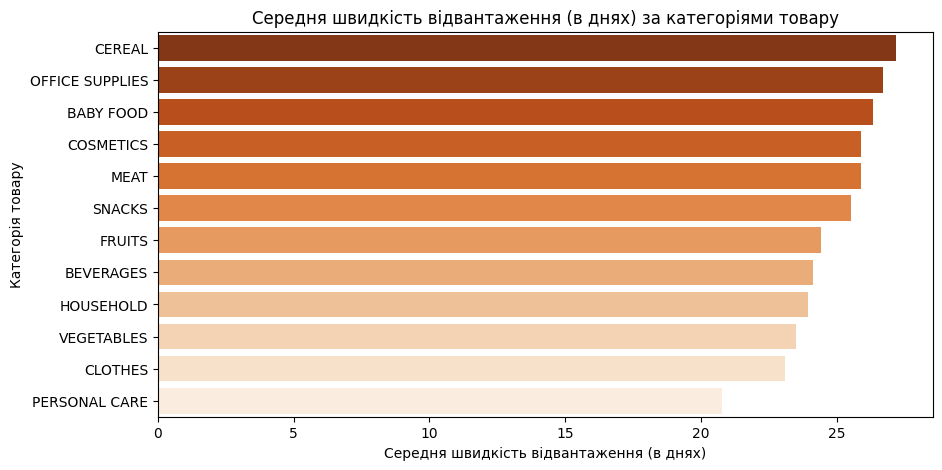

In [ ]:
df_final['Days to Ship'] = (df_final['Ship Date'] - df_final['Order Date']).dt.days
region_shipping_by_Product_Category = df_final.groupby('Product Category')['Days to Ship'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=region_shipping_by_Product_Category, x='Days to Ship', y='Product Category', palette='Oranges_r')
plt.title('Середня швидкість відвантаження (в днях) за категоріями товару')
plt.xlabel('Середня швидкість відвантаження (в днях)')
plt.ylabel('Категорія товару')
plt.show()

/tmp/ipykernel_1948/1989855169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_shipping_by_Country_Name, x='Days to Ship', y='Country Name', palette='Oranges_r')


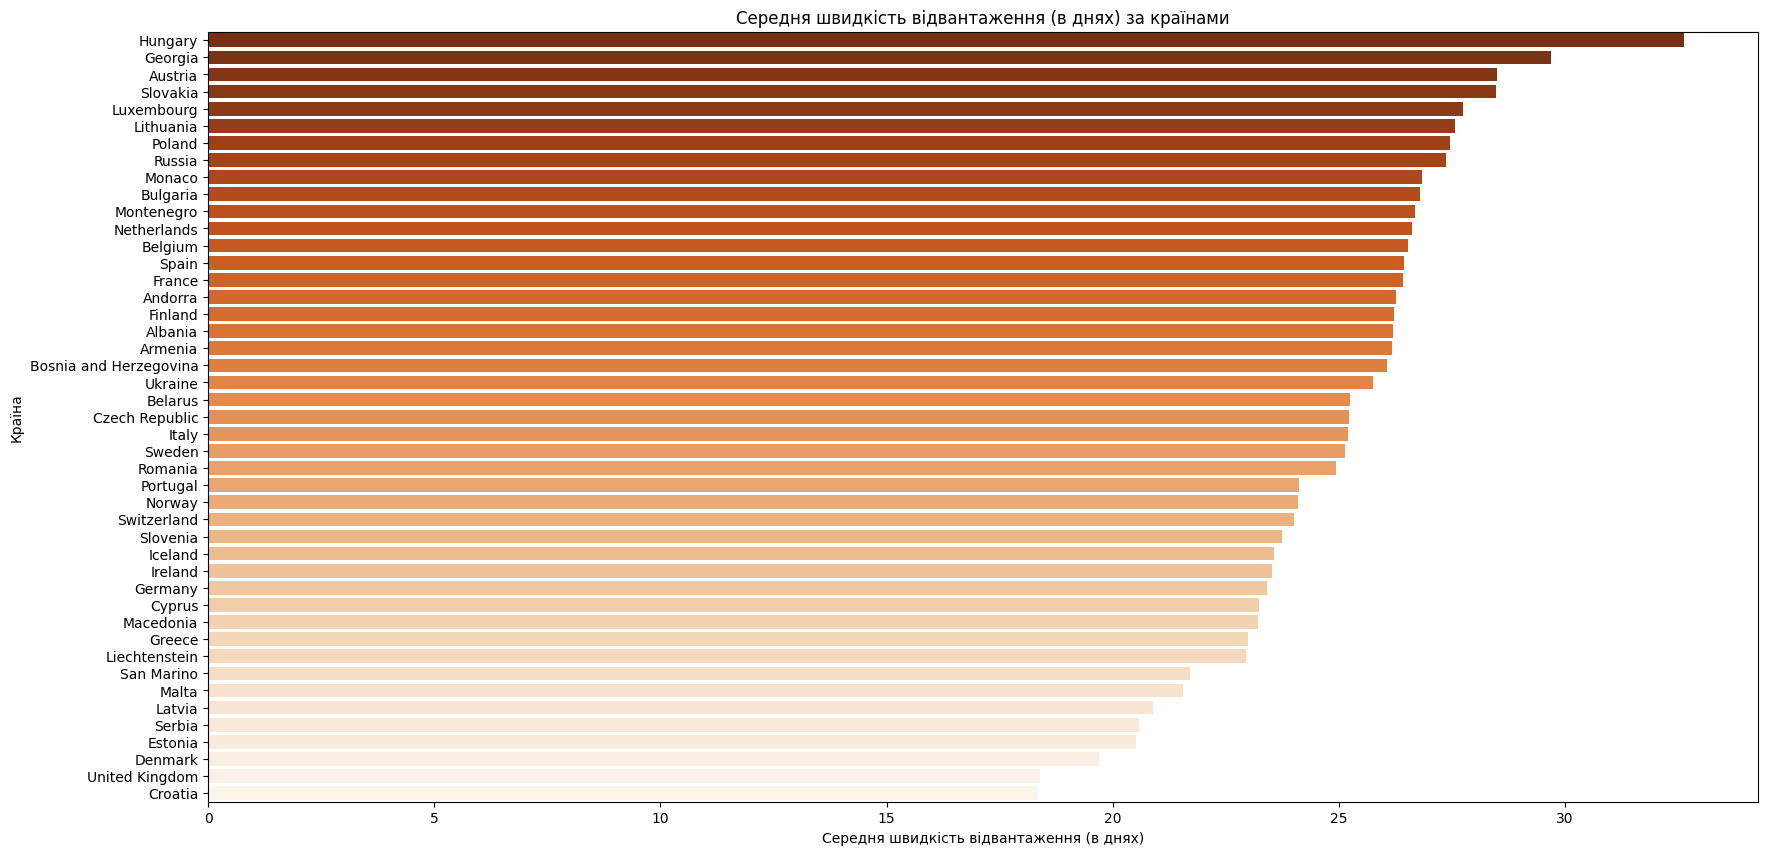

In [ ]:
df_final['Days to Ship'] = (df_final['Ship Date'] - df_final['Order Date']).dt.days
region_shipping_by_Country_Name = df_final.groupby('Country Name')['Days to Ship'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(20, 10))
sns.barplot(data=region_shipping_by_Country_Name, x='Days to Ship', y='Country Name', palette='Oranges_r')
plt.title('Середня швидкість відвантаження (в днях) за країнами')
plt.xlabel('Середня швидкість відвантаження (в днях)')
plt.ylabel('Країна')
plt.show()

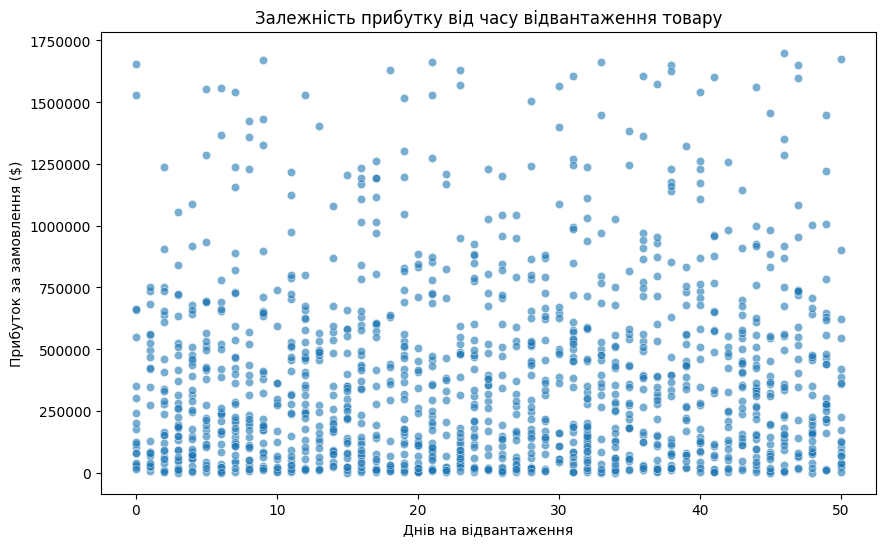

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Days to Ship', y='Profit', alpha=0.6)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Залежність прибутку від часу відвантаження товару')
plt.xlabel('Днів на відвантаження')
plt.ylabel('Прибуток за замовлення ($)')
plt.show()

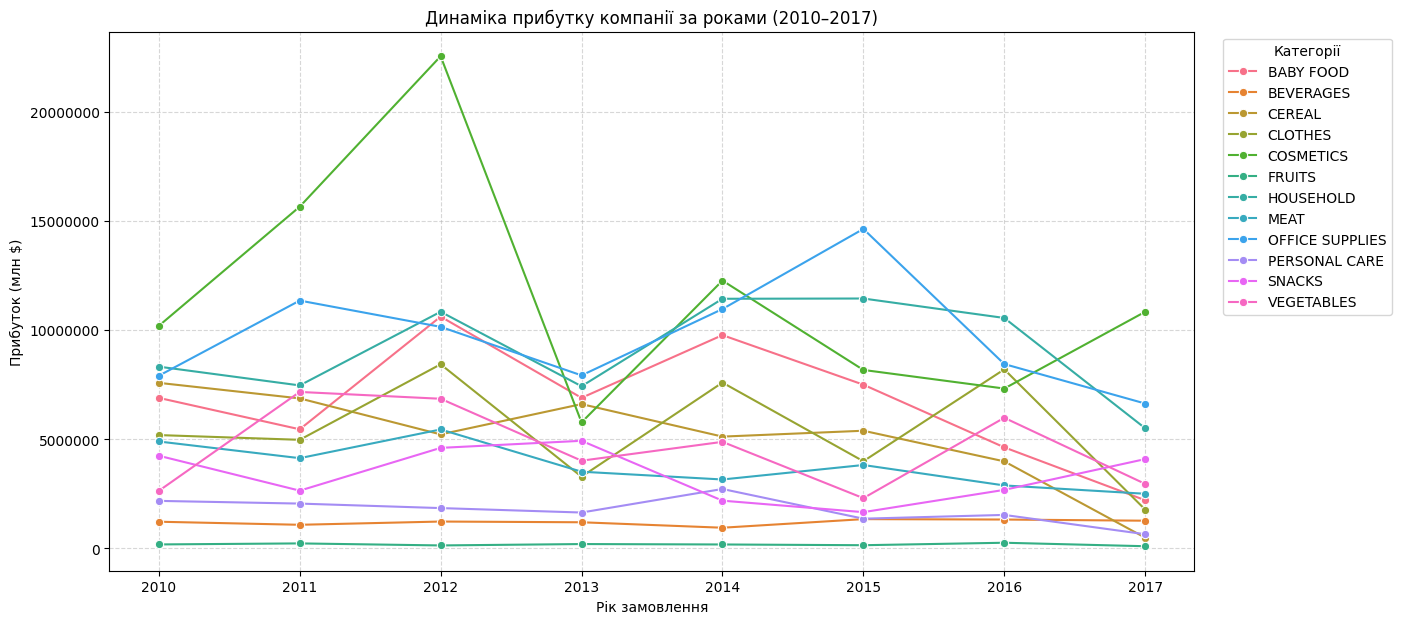

In [ ]:
df_final['Order Year'] = df_final['Order Date'].dt.year

yearly_category_profit = df_final.groupby(['Order Year', 'Product Category'])['Profit'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_category_profit, x='Order Year', y=yearly_category_profit['Profit'],
             hue='Product Category', marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Динаміка прибутку компанії за роками (2010–2017)')
plt.xlabel('Рік замовлення')
plt.ylabel('Прибуток (млн $)')
plt.xticks(yearly_category_profit['Order Year'].unique())
plt.legend(title='Категорії', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

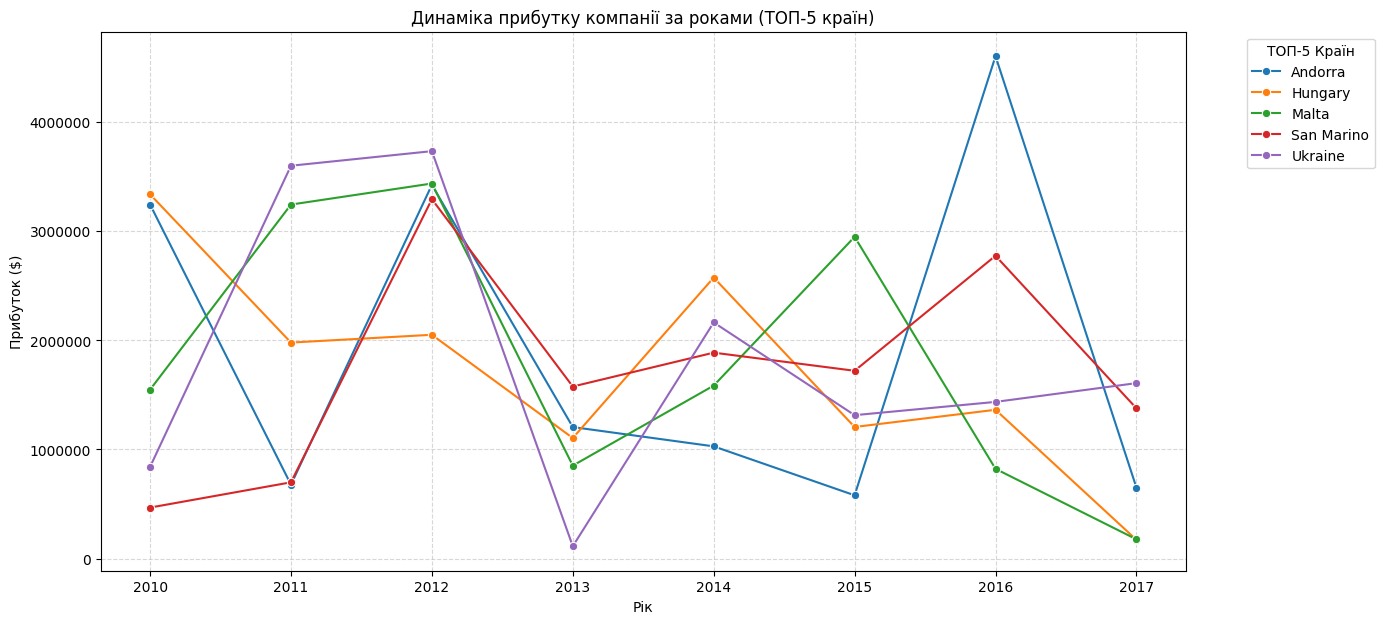

In [ ]:
df_final['Order Year'] = df_final['Order Date'].dt.year
top5_countries_list = df_final.groupby('Country Name')['Profit'].sum().sort_values(ascending=False).head(5).index
df_top5 = df_final[df_final['Country Name'].isin(top5_countries_list)]

time_analysis_top5 = df_top5.groupby(['Order Year', 'Country Name'])['Profit'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=time_analysis_top5,
    x='Order Year',
    y='Profit',
    hue='Country Name',
    marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Динаміка прибутку компанії за роками (ТОП-5 країн)')
plt.xlabel('Рік')
plt.ylabel('Прибуток ($)')
plt.xticks(time_analysis_top5['Order Year'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='ТОП-5 Країн')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

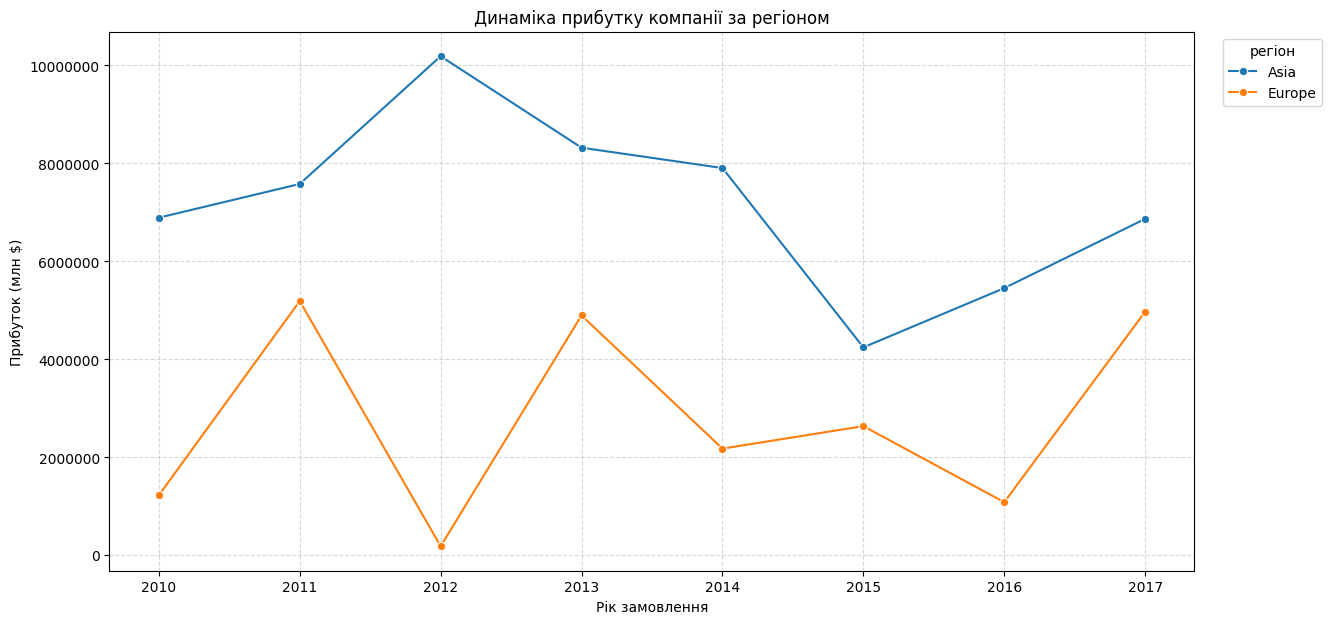

In [ ]:
df_final['Order Year'] = df_final['Order Date'].dt.year

region_category_profit = df_final.groupby(['Order Year', 'region'])['Profit'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=region_category_profit, x='Order Year', y=yearly_category_profit['Profit'],
             hue='region', marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Динаміка прибутку компанії за регіоном')
plt.xlabel('Рік замовлення')
plt.ylabel('Прибуток (млн $)')
plt.xticks(yearly_category_profit['Order Year'].unique())
plt.legend(title='регіон', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_final['Day of Week'] = pd.Categorical(df_final['Order Date'].dt.day_name(), categories=days_order, ordered=True)

weekly_matrix = df_final.pivot_table(
    index='Product Category',
    columns='Day of Week',
    values='Order ID',
    aggfunc='count',
    fill_value=0)
weekly_matrix

/tmp/ipykernel_15970/3305377635.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  weekly_matrix = df_final.pivot_table(


Day of Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Product Category,,,,,,,
BABY FOOD,17,16,16,13,16,19,15
BEVERAGES,21,18,16,18,12,15,21
CEREAL,12,14,16,13,12,21,15
CLOTHES,13,21,12,14,10,16,19
COSMETICS,12,16,17,15,28,14,12
FRUITS,19,14,14,10,8,23,24
HOUSEHOLD,19,6,22,10,17,12,11
MEAT,20,17,16,13,13,17,14
OFFICE SUPPLIES,15,15,22,16,19,15,21


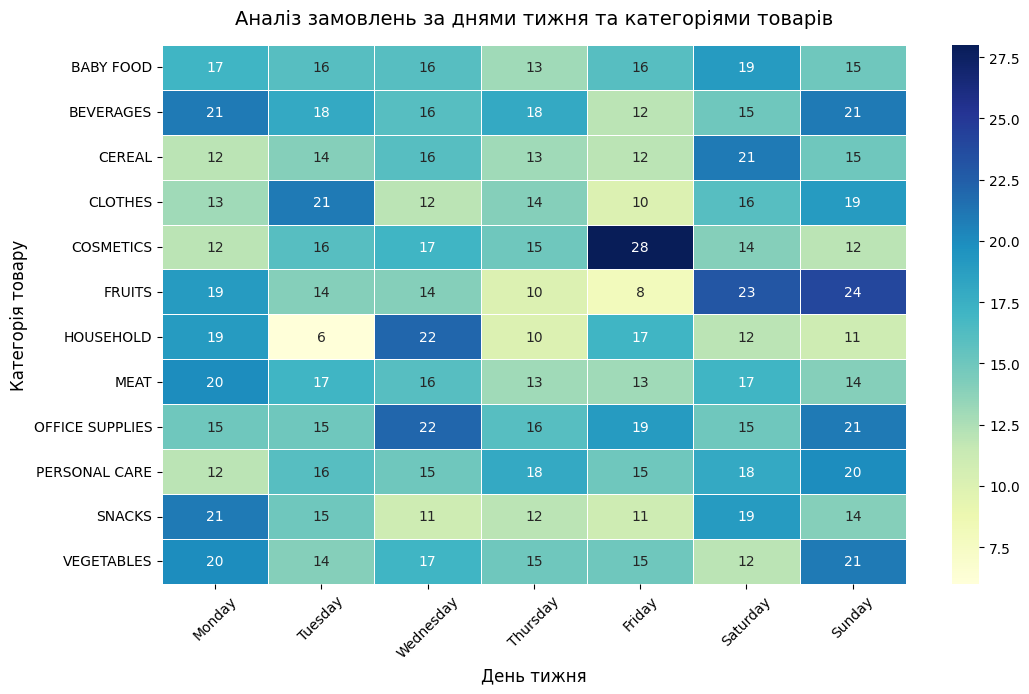

In [ ]:
plt.figure(figsize=(12, 7))
sns.heatmap(weekly_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title('Аналіз замовлень за днями тижня та категоріями товарів', fontsize=14, pad=15)
plt.xlabel('День тижня', fontsize=12)
plt.ylabel('Категорія товару', fontsize=12)
plt.xticks(rotation=45)

plt.show()

##Reporting
На основі проведеного аналізу можна зробити наступні ключові висновки та надати рекомендації:

* Найбільш Прибуткові Категорії: COSMETICS, OFFICE SUPPLIES та HOUSEHOLD є лідерами за прибутковістю. Слід зосередити маркетингові зусилля та розширення асортименту саме на цих категоріях.
* Канали Продажу: Прибутковість онлайн та офлайн каналів продажів є майже однаковою. Це свідчить про збалансовану стратегію, яку варто підтримувати, можливо, інвестуючи в оптимізацію обох напрямків.
* Регіональна Ефективність: Європа є найбільш прибутковим регіоном. Необхідно проаналізувати фактори успіху в Європі та спробувати застосувати їх в інших регіонах, таких як Азія, для підвищення їхньої прибутковості.
* Швидкість Відвантаження: відсутність залежності між терміном відвантаження товарів та їхньою вартістю. Ьожливо варто ввести меншу швидуість завантаження чи відвантаження для дорогих товарів, або ввести додаткову функцію з пришвидшенням відвантаження за додаткову плату, для збільшення прибутку компанії
* Динаміка Прибутку:Cosmetics, Office Supplies та Household є лідерами прибутку компанії. Вони формують ядро фінансової стабільності бізнесу,Snacks та Personal Care показують стабільно низькі результати без будь-яких ознак зростання протягом усього досліджуваного періоду
* Сезонність та Щотижневі Патерни: лінійний графік продажів по місяцях показує стрибки для більшості категорій. Жоден товар не демонструє класичної сезонної залежності від пори року. Категорії-лідери за загальним прибутком (Cosmetics, Office Supplies, Household) формують найбільші піки замовлень у штуках (до 80-100 тис. одиниць на місяць), (Personal Care, Snacks) тримаються у нижньому діапазоні (20-40 тис. одиниць) із значно меншою амплітудою коливань